# Depth analysis

In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import yaml

REPO = Path.cwd().parent
EXP = REPO / "experiments"
DATA = REPO / "data" / "link_prediction"
Path("figures").mkdir(exist_ok=True)

COL = {1: "tab:blue", 2: "tab:orange", 3: "tab:green"}
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

rows = []
for f in sorted(EXP.iterdir()):
    if not (f / "config.yaml").exists():
        continue
    cfg = yaml.safe_load(open(f / "config.yaml"))
    dataset = Path(cfg["data_dir"]).name
    rows.append({"run": f.name, "dataset": dataset, "L": int(cfg["num_layers"]), "encoding": cfg["encoding_scheme"],
                 "aggregations": ",".join(cfg["aggregations"]), "theta_der": float(cfg["derivation_threshold"]),
                 "target": cfg.get("target_predicate"), "lr": cfg.get("learning_rate"),
                 "epochs": len(pd.read_csv(f / "train_loss.tsv", sep="\t")),
                 "folder": f, "data_dir": DATA / dataset})
runs = pd.DataFrame(rows).sort_values(["dataset", "L"]).reset_index(drop=True)

GROUPS = {"WN18RRv1": (["WN18RRv1"], "wn18rrv1_benchmark"),
          "ADNI connectomes": (["data_v10", "seed_81"], "adni_connectomes")}
runs.drop(columns=["folder", "data_dir"])

,run,dataset,L,encoding,aggregations,theta_der,target,lr,epochs
0,WN18RRv1_L1,WN18RRv1,1,iclr22,max,0.0001,NaN,0.010,972
1,WN18RRv1_L2,WN18RRv1,2,iclr22,"max,max",0.0001,NaN,0.010,576
2,WN18RRv1_L3,WN18RRv1,3,iclr22,"max,max,max",0.0001,NaN,0.010,648
3,data_v10_L1,data_v10,1,canonical,max,0.0001,positive,0.001,315
4,data_v10_L2,data_v10,2,canonical,"max,max",0.0001,positive,0.001,15039
5,data_v10_L3,data_v10,3,canonical,"max,max,max",0.0001,positive,0.001,6844
6,seed_81_L1,seed_81,1,canonical,max,0.0001,positive,0.001,425
7,seed_81_L2,seed_81,2,canonical,"max,max",0.0001,positive,0.001,10026
8,seed_81_L3,seed_81,3,canonical,"max,max,max",0.0001,positive,0.001,3347


In [2]:
def read_tsv(path, cols):
    return pd.read_csv(path, sep="\t", header=None, names=cols, dtype=str, quoting=3, keep_default_na=False)

def read_metrics(path):
    lines = open(path).read().splitlines()
    table = [l.split("\t") for l in lines[1:] if not l.startswith("Area")]
    df = pd.DataFrame(table, columns=["threshold", "precision", "recall", "accuracy", "f1"]).astype(float)
    auprc = next((float(l.split(":")[1]) for l in lines if l.startswith("Area")), None)
    return df, auprc

def example_scores(run):
    """scores the model gave the test positives / negatives (0 if the fact was not derived), plus all derived facts"""
    pred = read_tsv(run.folder / "predicted_triples_scored.tsv", ["s", "p", "o", "score"])
    pred["score"] = pred["score"].astype(float)
    lookup = dict(zip(zip(pred.s, pred.p, pred.o), pred.score))
    pos = read_tsv(run.data_dir / "test_pos.tsv", ["s", "p", "o"])
    neg = read_tsv(run.data_dir / "test_neg.tsv", ["s", "p", "o"])
    ps = np.array([lookup.get(t, 0.0) for t in zip(pos.s, pos.p, pos.o)])
    ns = np.array([lookup.get(t, 0.0) for t in zip(neg.s, neg.p, neg.o)])
    return ps, ns, pred

## Metrics

In [3]:
from sklearn.metrics import roc_auc_score, average_precision_score

sweeps, scores, recs = {}, {}, []
for _, r in runs.iterrows():
    sweep, auprc = read_metrics(r.folder / "test_metrics.txt")
    at_theta = read_metrics(r.folder / "test_at_valid_threshold.txt")[0].iloc[0]
    ps, ns, pred = example_scores(r)
    y = np.r_[np.ones(len(ps)), np.zeros(len(ns))]; s = np.r_[ps, ns]
    sweeps[r.run] = sweep; scores[r.run] = (ps, ns)
    recs.append({"dataset": r.dataset, "L": r.L, "epochs": r.epochs, "theta (valid)": at_theta.threshold,
                 "precision": at_theta.precision, "recall": at_theta.recall, "F1": at_theta.f1,
                 "AUPRC": auprc, "AP": average_precision_score(y, s), "AUROC": roc_auc_score(y, s),
                 "n_pos": len(ps), "n_neg": len(ns), "facts derived": len(pred)})
results = pd.DataFrame(recs)
results.to_csv("results_by_depth.csv", index=False)
for name, (dsets, _) in GROUPS.items():
    print(name)
    display(results[results.dataset.isin(dsets)].round(3))

WN18RRv1


,dataset,L,epochs,theta (valid),precision,recall,F1,AUPRC,AP,AUROC,n_pos,n_neg,facts derived
0,WN18RRv1,1,972,0.01,0.981,0.927,0.953,0.943,0.957,0.940,165,165,11056
1,WN18RRv1,2,576,0.01,0.987,0.921,0.953,0.946,0.961,0.947,165,165,7902
2,WN18RRv1,3,648,0.01,0.981,0.927,0.953,0.947,0.963,0.949,165,165,7741


ADNI connectomes


,dataset,L,epochs,theta (valid),precision,recall,F1,AUPRC,AP,AUROC,n_pos,n_neg,facts derived
3,data_v10,1,315,0.00,0.484,1.0,0.652,0.242,0.484,0.500,15,16,31
4,data_v10,2,15039,0.70,0.529,0.6,0.562,0.524,0.575,0.587,15,16,30
5,data_v10,3,6844,0.00,0.536,1.0,0.698,0.546,0.603,0.631,15,16,235
6,seed_81,1,425,0.48,0.333,0.4,0.364,0.317,0.402,0.290,10,10,20
7,seed_81,2,10026,0.00,0.500,1.0,0.667,0.497,0.574,0.550,10,10,20
8,seed_81,3,3347,0.00,0.500,1.0,0.667,0.464,0.511,0.510,10,10,711


## Loss plot

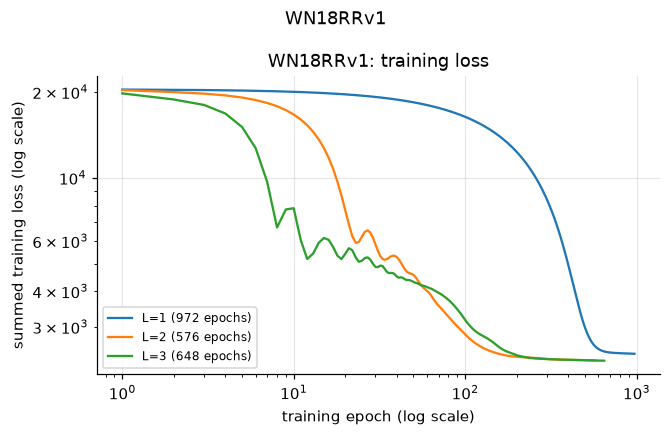

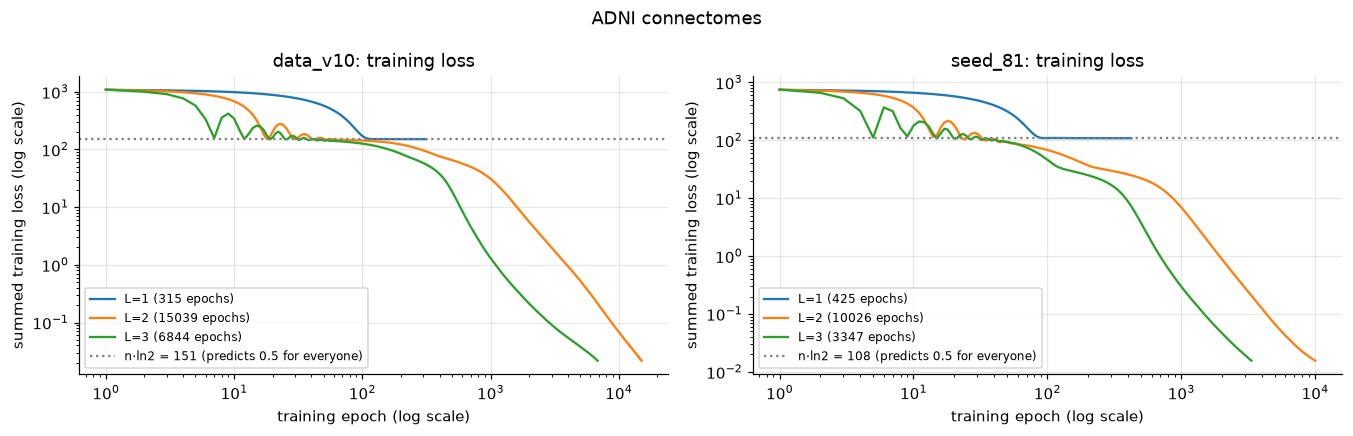

In [4]:
for name, (dsets, stem) in GROUPS.items():
    fig, axes = plt.subplots(1, len(dsets), figsize=(6.2 * len(dsets), 4), squeeze=False)
    for ax, ds in zip(axes[0], dsets):
        sub = runs[runs.dataset == ds]
        for _, r in sub.iterrows():
            log = pd.read_csv(r.folder / "train_loss.tsv", sep="\t")
            ax.plot(log.epoch + 1, log.loss, color=COL[r.L], label=f"L={r.L} ({len(log)} epochs)")
        if pd.notna(sub.iloc[0].target):                     # ADNI: loss over the labelled patients only
            n = sum(len(read_tsv(sub.iloc[0].data_dir / f, ["s", "p", "o"])) for f in ["train_pos.tsv", "train_neg.tsv"])
            ax.axhline(n * np.log(2), ls=":", color="grey", label=f"n·ln2 = {n*np.log(2):.0f} (predicts 0.5 for everyone)")
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set(xlabel="training epoch (log scale)", ylabel="summed training loss (log scale)", title=f"{ds}: training loss")
        ax.legend(loc="lower left", fontsize=8)
    fig.suptitle(name); plt.tight_layout(); plt.savefig(f"figures/loss_curves_{stem}.png"); plt.show()

## PR curves

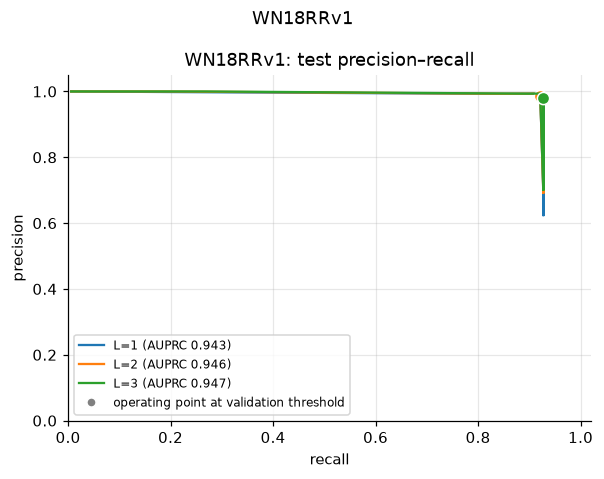

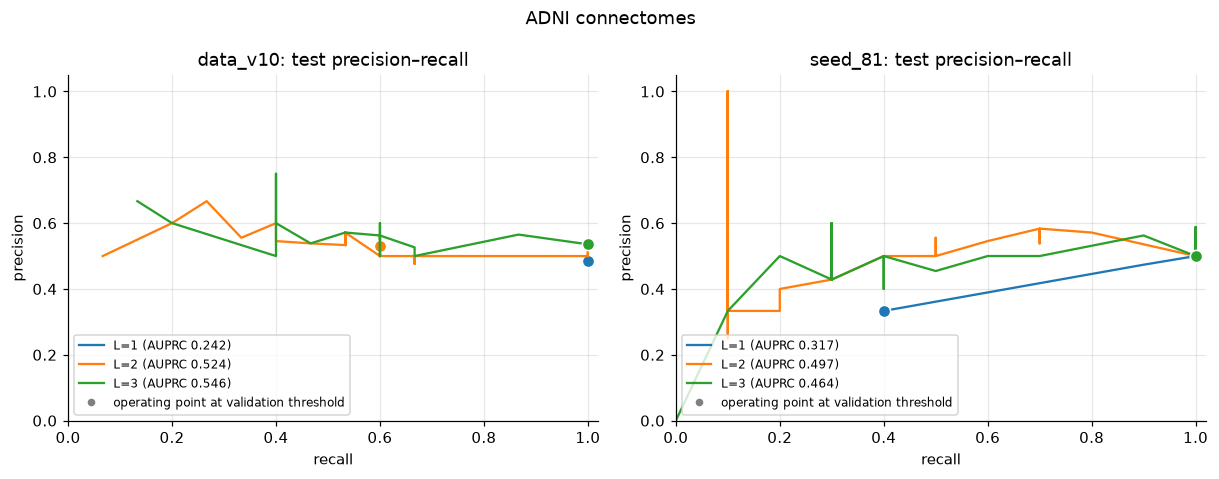

In [5]:
for name, (dsets, stem) in GROUPS.items():
    fig, axes = plt.subplots(1, len(dsets), figsize=(5.6 * len(dsets), 4.4), squeeze=False)
    for ax, ds in zip(axes[0], dsets):
        for _, r in runs[runs.dataset == ds].iterrows():
            row = results[(results.dataset == ds) & (results.L == r.L)].iloc[0]
            sw = sweeps[r.run].dropna().sort_values("recall")
            ax.plot(sw.recall, sw.precision, color=COL[r.L], label=f"L={r.L} (AUPRC {row.AUPRC:.3f})")
            ax.plot(row.recall, row.precision, "o", color=COL[r.L], ms=8, mec="white")
        ax.plot([], [], "o", color="grey", mec="white", label="operating point at validation threshold")
        ax.set(xlim=(0, 1.02), ylim=(0, 1.05), xlabel="recall", ylabel="precision", title=f"{ds}: test precision–recall")
        ax.legend(loc="lower left", fontsize=8)
    fig.suptitle(name); plt.tight_layout(); plt.savefig(f"figures/pr_curves_{stem}.png"); plt.show()

## F1 against decision threshold

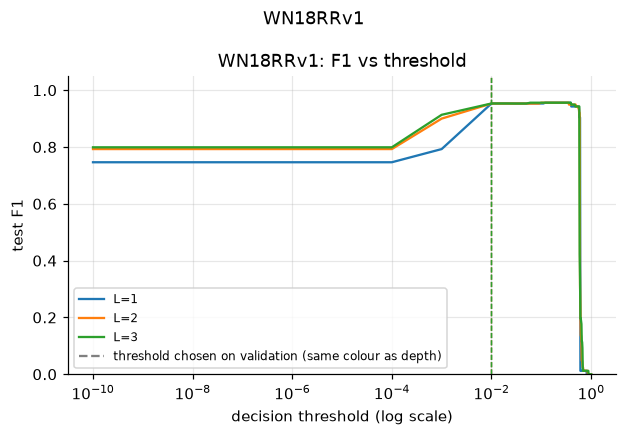

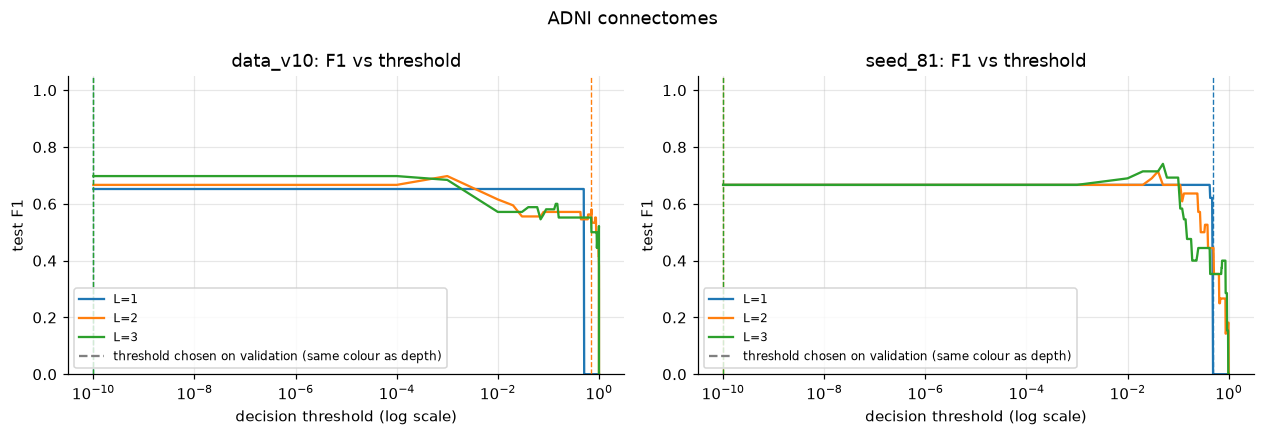

In [6]:
for name, (dsets, stem) in GROUPS.items():
    fig, axes = plt.subplots(1, len(dsets), figsize=(5.8 * len(dsets), 4), squeeze=False)
    for ax, ds in zip(axes[0], dsets):
        for _, r in runs[runs.dataset == ds].iterrows():
            sw = sweeps[r.run]
            ax.plot(sw.threshold.clip(lower=1e-10), sw.f1, color=COL[r.L], label=f"L={r.L}")
            th = results[(results.dataset == ds) & (results.L == r.L)]["theta (valid)"].iloc[0]
            ax.axvline(max(th, 1e-10), color=COL[r.L], lw=0.9, ls="--")
        handles = [Line2D([], [], color=COL[L], label=f"L={L}") for L in sorted(runs[runs.dataset == ds].L)]
        handles.append(Line2D([], [], color="grey", ls="--", label="threshold chosen on validation (same colour as depth)"))
        ax.set_xscale("log")
        ax.set(ylim=(0, 1.05), xlabel="decision threshold (log scale)", ylabel="test F1", title=f"{ds}: F1 vs threshold")
        ax.legend(handles=handles, loc="lower left", fontsize=8)
    fig.suptitle(name); plt.tight_layout(); plt.savefig(f"figures/f1_vs_threshold_{stem}.png"); plt.show()

## Model scores

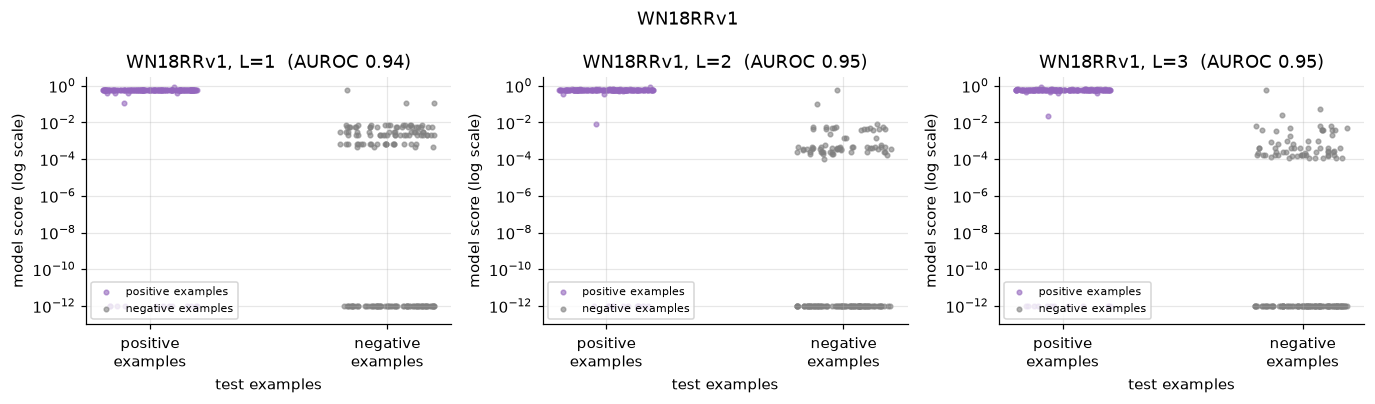

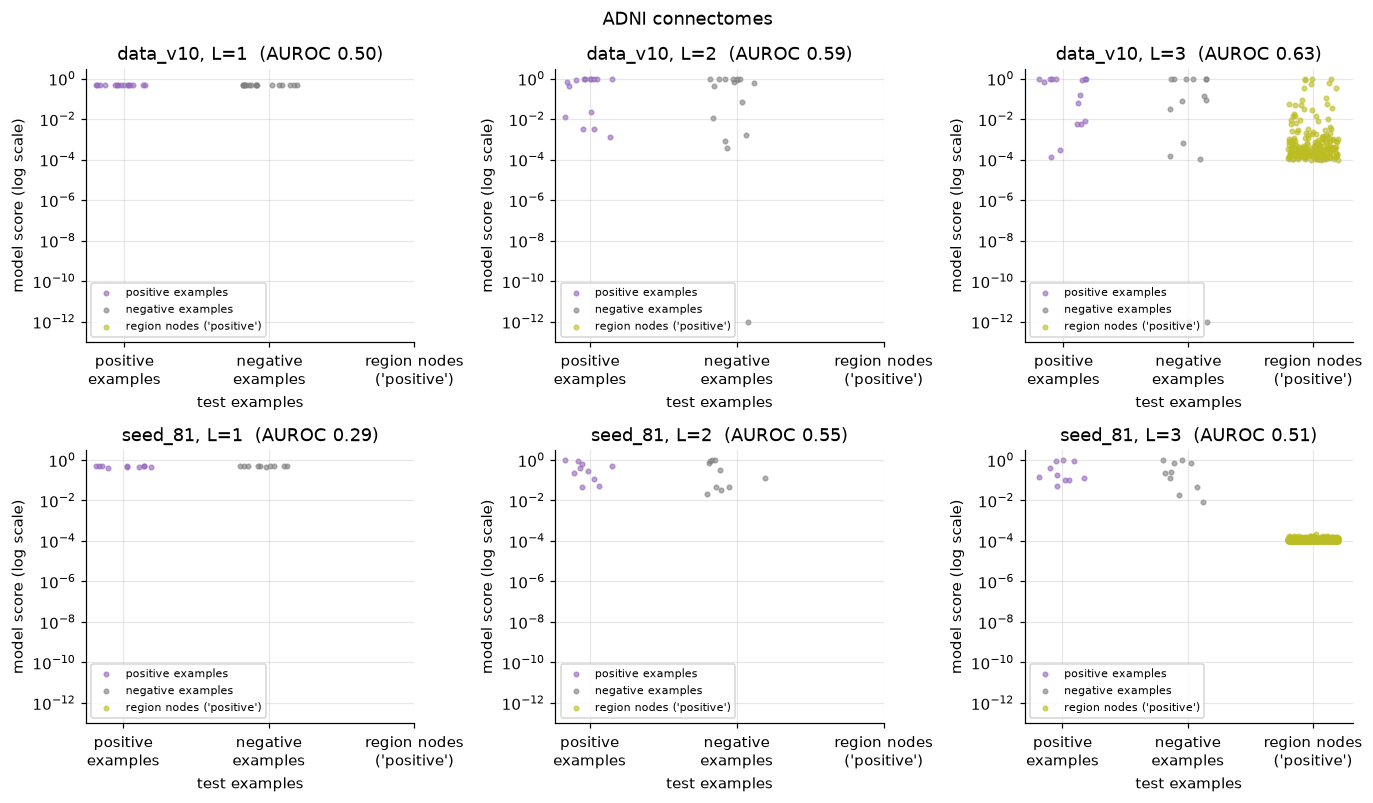

In [7]:
rng = np.random.default_rng(0)

for name, (dsets, stem) in GROUPS.items():
    Ls = sorted(runs[runs.dataset.isin(dsets)].L.unique())
    fig, axes = plt.subplots(len(dsets), len(Ls), figsize=(4.2 * len(Ls), 3.7 * len(dsets)), squeeze=False)
    for i, ds in enumerate(dsets):
        for j, L in enumerate(Ls):
            ax = axes[i, j]
            r = runs[(runs.dataset == ds) & (runs.L == L)].iloc[0]
            ps, ns = scores[r.run]
            groups = [("positive\nexamples", ps, "tab:purple"), ("negative\nexamples", ns, "grey")]
            if r.encoding == "canonical":           
                pred = example_scores(r)[2]
                patients = set(read_tsv(r.data_dir / "test_pos.tsv", ["s", "p", "o"]).s) | set(read_tsv(r.data_dir / "test_neg.tsv", ["s", "p", "o"]).s)
                others = pred[(pred.o == "positive") & (~pred.s.isin(patients))].score.to_numpy()
                groups.append(("region nodes\n('positive')", others, "tab:olive"))
            for k, (lab, arr, colr) in enumerate(groups):
                ax.scatter(k + rng.uniform(-0.2, 0.2, len(arr)), np.clip(arr, 1e-12, None), s=9, alpha=0.6, color=colr, label=lab.replace("\n", " "))
            auroc = results[(results.dataset == ds) & (results.L == L)].AUROC.iloc[0]
            ax.set_yscale("log")
            ax.set(xticks=range(len(groups)), xticklabels=[g[0] for g in groups], ylim=(1e-13, 3),
                   xlabel="test examples", ylabel="model score (log scale)", title=f"{ds}, L={L}  (AUROC {auroc:.2f})")
            ax.legend(loc="lower left", fontsize=7)
    fig.suptitle(name); plt.tight_layout(); plt.savefig(f"figures/scores_{stem}.png"); plt.show()

## Test metrics

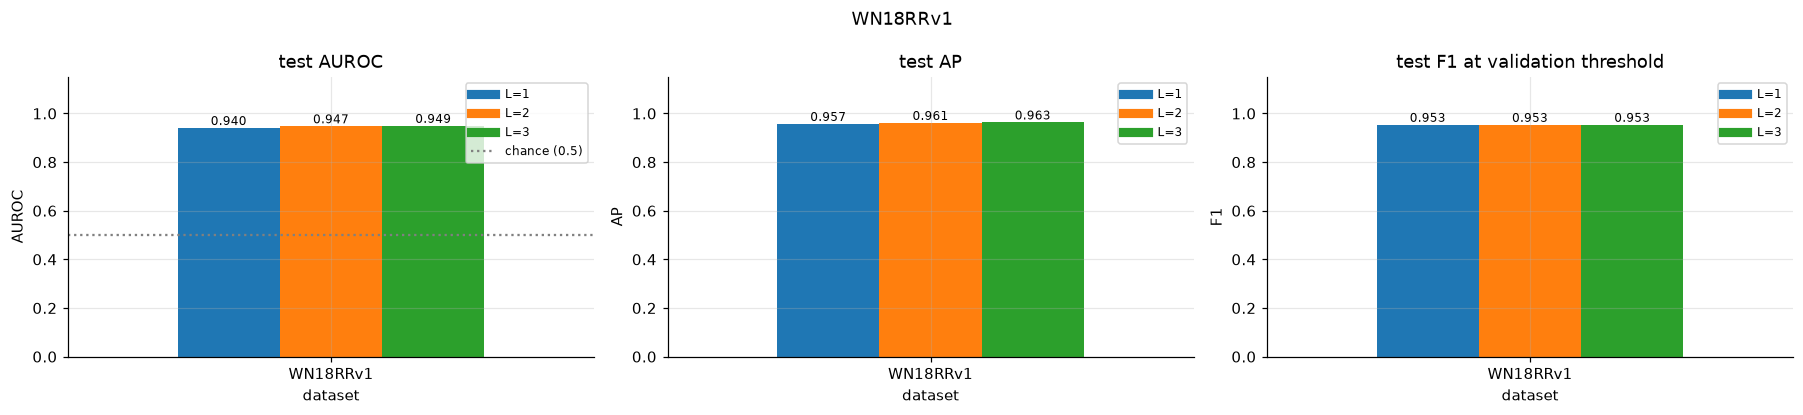

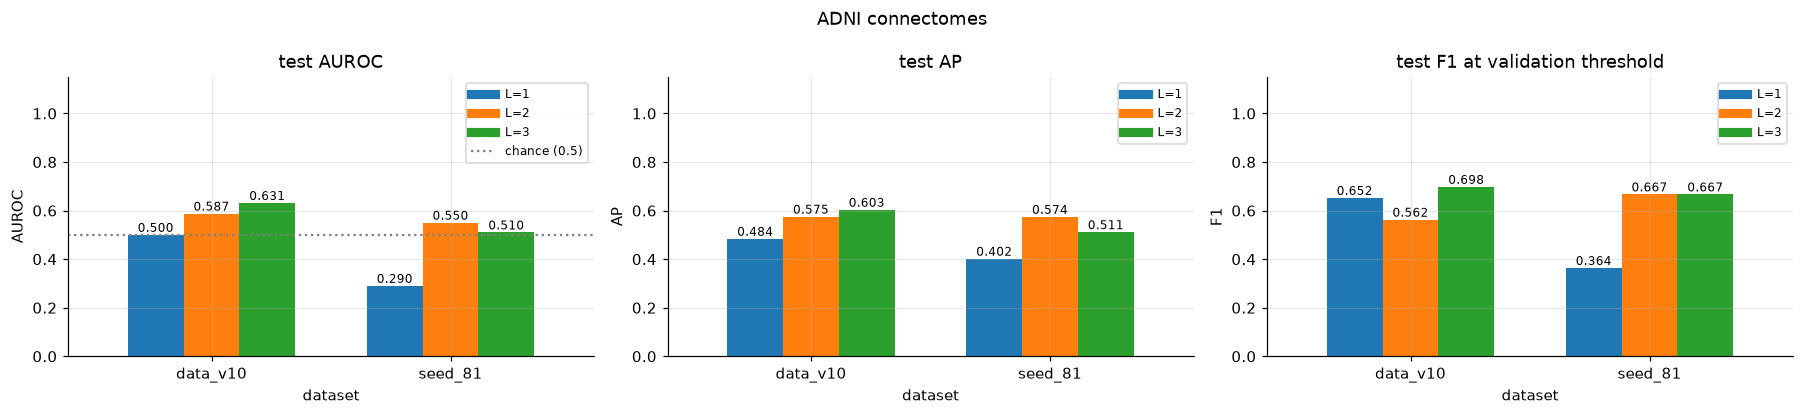

In [8]:
for name, (dsets, stem) in GROUPS.items():
    sub = results[results.dataset.isin(dsets)]
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 3.8))
    for ax, m in zip(axes, ["AUROC", "AP", "F1"]):
        piv = sub.pivot(index="dataset", columns="L", values=m)
        piv.plot.bar(ax=ax, color=[COL[L] for L in piv.columns], rot=0, legend=False, width=0.7)
        for cont in ax.containers:
            ax.bar_label(cont, fmt="%.3f", fontsize=8)
        handles = [Line2D([], [], color=COL[L], lw=6, label=f"L={L}") for L in piv.columns]
        if m == "AUROC":
            ax.axhline(0.5, ls=":", color="grey")
            handles.append(Line2D([], [], color="grey", ls=":", label="chance (0.5)"))
        ax.set(ylim=(0, 1.15), ylabel=m, title=f"test {m}" + (" at validation threshold" if m == "F1" else ""))
        ax.legend(handles=handles, loc="upper right", fontsize=8)
    fig.suptitle(name); plt.tight_layout(); plt.savefig(f"figures/depth_bars_{stem}.png"); plt.show()

## Extracted rules

WN18RRv1


,dataset,L,explained fact,body atoms,distinct predicates
0,WN18RRv1,1,"('00084230', '_derivationally_related_form', '...",2,2
1,WN18RRv1,2,"('00084230', '_derivationally_related_form', '...",24,3
2,WN18RRv1,3,"('00084230', '_derivationally_related_form', '...",372,3


ADNI connectomes


,dataset,L,explained fact,body atoms,distinct predicates
3,data_v10,1,"('041_S_0679', 'http://www.w3.org/1999/02/22-r...",188,95
4,data_v10,2,"('129_S_6244', 'http://www.w3.org/1999/02/22-r...",4601,104
5,data_v10,3,"('129_S_6244', 'http://www.w3.org/1999/02/22-r...",780160,98
6,seed_81,1,"('sub-ADNI003S6924_ses-M000', 'http://www.w3.o...",232,117
7,seed_81,2,"('sub-ADNI168S6735_ses-M000', 'http://www.w3.o...",19136,126
8,seed_81,3,"('sub-ADNI035S6950_ses-M000', 'http://www.w3.o...",662799,127


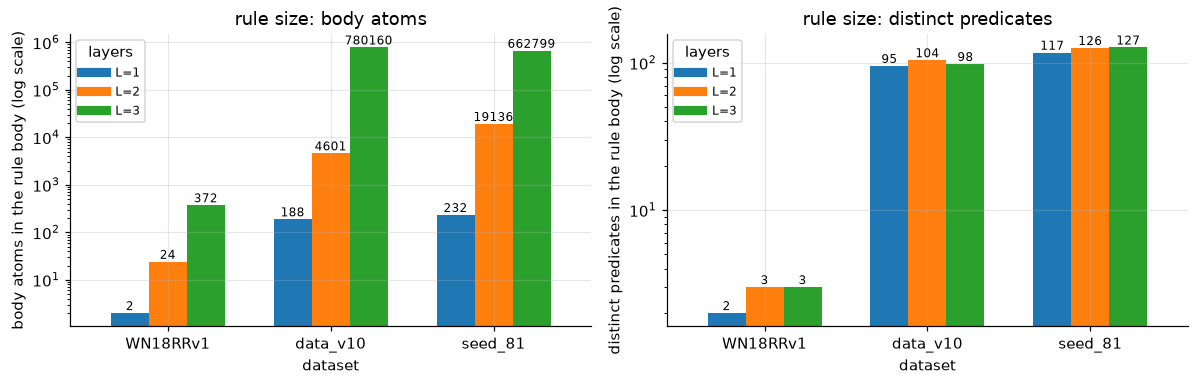

In [9]:
rows = []
for _, r in runs.iterrows():
    fact, rule = open(r.folder / "explanations.txt").read().splitlines()[:2]
    body = rule.split(":-", 1)[1] if ":-" in rule else ""
    preds = re.findall(r"<([^>]+)>\[", body)                 # one match per body atom
    rows.append({"dataset": r.dataset, "L": r.L, "explained fact": fact[:60],
                 "body atoms": len(preds), "distinct predicates": len(set(preds) - {"top-pred"})})
rules = pd.DataFrame(rows)
for name, (dsets, _) in GROUPS.items():
    print(name); display(rules[rules.dataset.isin(dsets)])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, colname in zip(axes, ["body atoms", "distinct predicates"]):
    piv = rules.pivot(index="dataset", columns="L", values=colname)
    piv.plot.bar(ax=ax, color=[COL[L] for L in piv.columns], rot=0, width=0.7, legend=False)
    for cont in ax.containers:
        ax.bar_label(cont, fontsize=8)
    ax.set_yscale("log")
    ax.set(xlabel="dataset", ylabel=f"{colname} in the rule body (log scale)", title=f"rule size: {colname}")
    ax.legend(handles=[Line2D([], [], color=COL[L], lw=6, label=f"L={L}") for L in piv.columns], title="layers", loc="upper left", fontsize=8)
plt.tight_layout(); plt.savefig("figures/rule_size.png"); plt.show()